# PI-MMM
## Physics-Informed Marketing Mix Modeling
### Quickstart Guide

#### Installation

In [ ]:
!pip install git+https://github.com/lgpintomkt/pimmm.git

#### Synthetic Data for Examples

In [18]:
# ============================================================
# Imports, Setup, and Synthetic Data Generation
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier

# Import PI-MMM components
from pimmm import PhysicsInformedMMM, TabFMResponseWrapper, MeridianResponseWrapper

# Set plotting aesthetics for Jupyter
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Generate synthetic timeline and spend channels
np.random.seed(42)
t_eval = np.arange(0, 25, 0.5)

spend_data = np.column_stack([
    2.0 + 1.5 * np.sin(0.2 * t_eval),  # Channel 1 spend
    1.0 + 0.8 * np.cos(0.1 * t_eval)   # Channel 2 spend
])

# Observed market penetration trajectory (0 to 1 scale)
F_obs = np.clip(np.cumsum(np.mean(spend_data, axis=1)) * 0.015, 0, 1)

# Split into early adoption phase training (F <= 20% penetration)
cutoff = np.where(F_obs <= 0.20)[0][-1]
X_train, y_train = spend_data[:cutoff], F_obs[:cutoff]
t_train = t_eval[:cutoff]

print(f"Dataset generated across {len(t_eval)} time steps.")
print(f"Training on early adoption stage: {len(X_train)} points (Penetration <= {y_train[-1]*100:.1f}%)")

Dataset generated across 50 time steps.
Training on early adoption stage: 5 points (Penetration <= 15.3%)


## End-to-End Usage Examples
### Example 1: PI-MMM with Standard Scikit-Learn Model (e.g., Gradient Boosting)

--- Scikit-Learn (Gradient Boosting) Driver ---
  Innovation (p): 0.1000
  Imitation (q): 0.1000
  Scale Factor (gamma): 0.8036


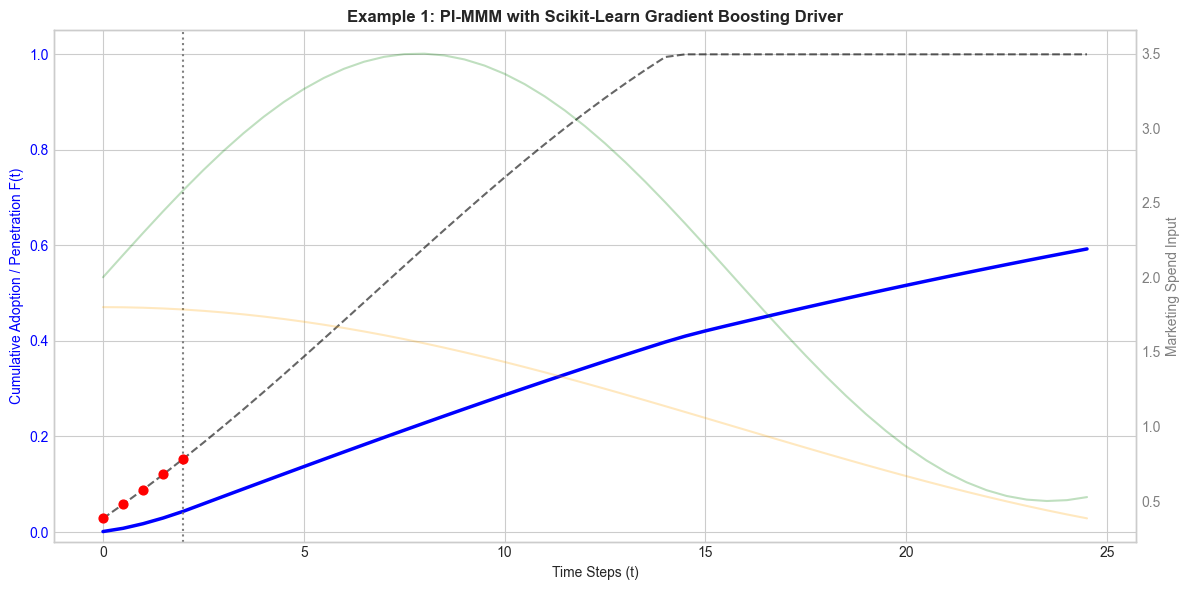

In [19]:
# ============================================================
# Cell 2: Example 1 - Scikit-Learn Gradient Boosting Driver
# ============================================================

# Initialize ML Driver and PI-MMM
ml_driver = GradientBoostingRegressor(random_state=42)
pimmm_gb = PhysicsInformedMMM(response_model=ml_driver, dt=0.5)

# Fit on early adoption phase
pimmm_gb.fit(X_train, y_train)

# Forecast full adoption trajectory
F_pred_gb = pimmm_gb.predict(spend_data)

# Print Summary
print("--- Scikit-Learn (Gradient Boosting) Driver ---")
for param, val in pimmm_gb.get_params_summary().items():
    print(f"  {param}: {val:.4f}")

# Plot Chart
fig, ax1 = plt.subplots()

# Primary axis: S-Curve
ax1.plot(t_eval, F_obs, 'k--', label='True Ground-Truth Curve', alpha=0.6)
ax1.plot(t_eval, F_pred_gb, 'b-', linewidth=2.5, label='PI-MMM Forecast (Gradient Boosting)')
ax1.scatter(t_train, y_train, color='red', s=40, zorder=5, label='Early-Stage Training Data (<=20%)')
ax1.axvline(t_train[-1], color='gray', linestyle=':', label='Training Cutoff')

ax1.set_xlabel('Time Steps (t)')
ax1.set_ylabel('Cumulative Adoption / Penetration F(t)', color='blue')
ax1.set_ylim(-0.02, 1.05)
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary axis: Spend Input
ax2 = ax1.twinx()
ax2.plot(t_eval, spend_data[:, 0], color='green', alpha=0.25, linestyle='-', label='Channel 1 Spend')
ax2.plot(t_eval, spend_data[:, 1], color='orange', alpha=0.25, linestyle='-', label='Channel 2 Spend')
ax2.set_ylabel('Marketing Spend Input', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.grid(False)

plt.title('Example 1: PI-MMM with Scikit-Learn Gradient Boosting Driver', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## Example 2: PI-MMM with Google Meridian MMM

GOOGLE MERIDIAN MMM DRIVER RESULTS
Innovation (p): 0.0625
Imitation (q): 0.1970
Scale Factor (gamma): 0.8082


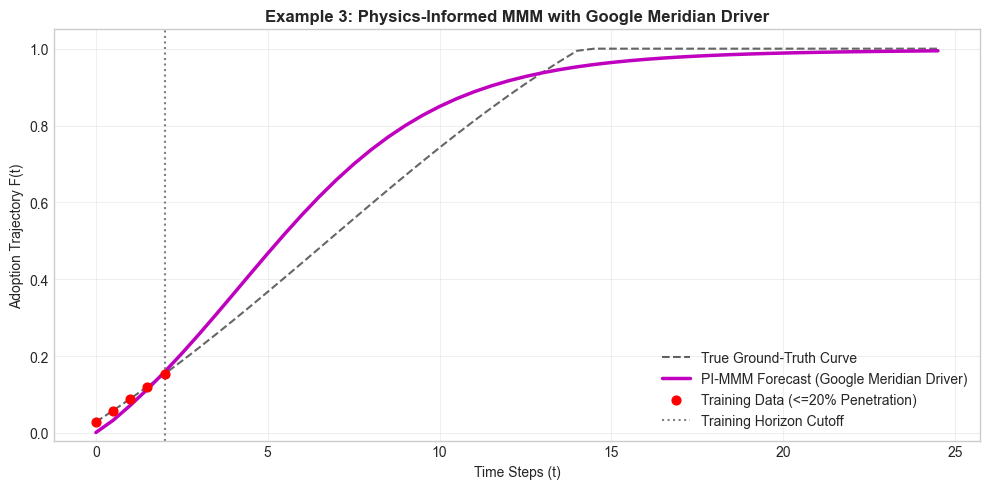

In [20]:
# ============================================================
# Example 2 - Google Meridian MMM Driver
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from pimmm import PhysicsInformedMMM, MeridianResponseWrapper

# 1. Setup synthetic test data
np.random.seed(42)
t_eval = np.arange(0, 25, 0.5)

spend_data = np.column_stack([
    2.0 + 1.5 * np.sin(0.2 * t_eval),
    1.0 + 0.8 * np.cos(0.1 * t_eval)
])

F_obs = np.clip(np.cumsum(np.mean(spend_data, axis=1)) * 0.015, 0, 1)
cutoff = np.where(F_obs <= 0.20)[0][-1]

X_train, y_train = spend_data[:cutoff], F_obs[:cutoff]
t_train = t_eval[:cutoff]

# 2. Mock Meridian instance emitting multi-dimensional transformation arrays
class MockGoogleMeridianModel:
    def predict_adstock(self, X):
        X_arr = np.asarray(X)
        adstocked = X_arr * 0.7 + np.roll(X_arr, shift=1, axis=0) * 0.3
        return adstocked

# 3. Instantiate Meridian wrapper and PI-MMM
meridian_backend = MockGoogleMeridianModel()
meridian_wrapper = MeridianResponseWrapper(meridian_model=meridian_backend)

pimmm_meridian = PhysicsInformedMMM(response_model=meridian_wrapper, dt=0.5)

# Fit PI-MMM over Meridian inputs
pimmm_meridian.fit(X_train, y_train)

# Predict continuous adoption trajectory
F_pred_meridian = pimmm_meridian.predict(spend_data)

# 4. Print recovered constants
print("=" * 50)
print("GOOGLE MERIDIAN MMM DRIVER RESULTS")
print("=" * 50)
for param, val in pimmm_meridian.get_params_summary().items():
    print(f"{param}: {val:.4f}")

# 5. Plot Inline Chart in Jupyter
plt.figure(figsize=(10, 5))
plt.plot(t_eval, F_obs, 'k--', label='True Ground-Truth Curve', alpha=0.6)
plt.plot(t_eval, F_pred_meridian, 'm-', linewidth=2.5, label='PI-MMM Forecast (Google Meridian Driver)')
plt.scatter(t_train, y_train, color='red', s=40, zorder=5, label='Training Data (<=20% Penetration)')
plt.axvline(t_train[-1], color='gray', linestyle=':', label='Training Horizon Cutoff')

plt.title('Example 3: Physics-Informed MMM with Google Meridian Driver', fontsize=12, fontweight='bold')
plt.xlabel('Time Steps (t)')
plt.ylabel('Adoption Trajectory F(t)')
plt.ylim(-0.02, 1.05)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Example 3: PI-MMM with TabFM (Tabular Foundation Model)

--- Tabular Foundation Model (TabFM Driver) ---
  Innovation (p): 0.1000
  Imitation (q): 0.8000
  Scale Factor (gamma): 0.8692


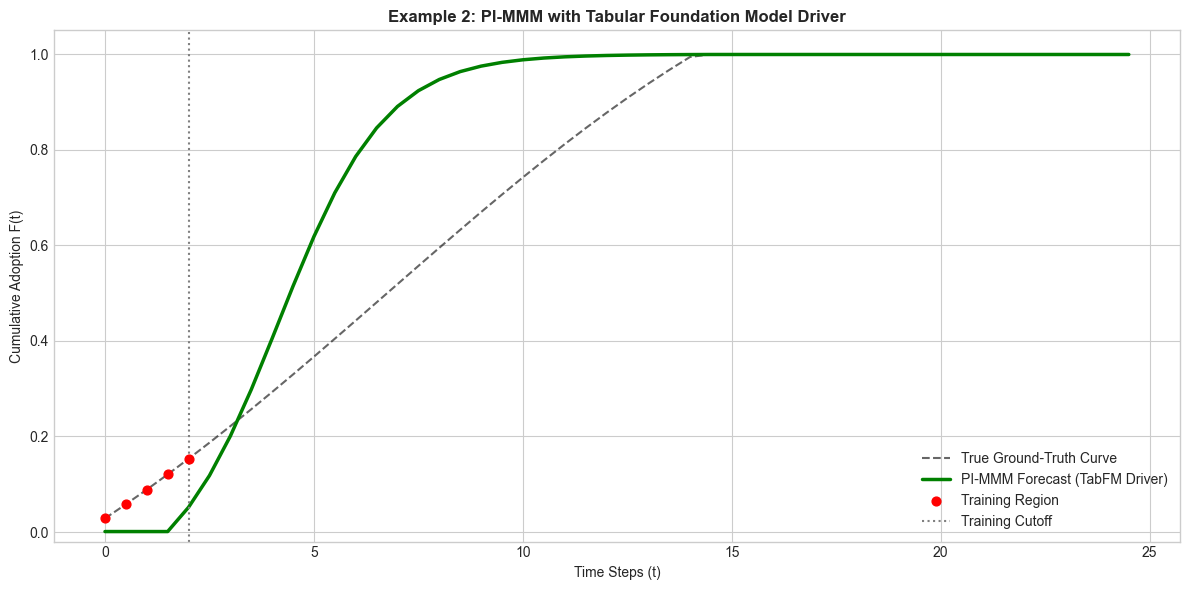

In [21]:
# ============================================================
# Example 3 - Tabular Foundation Model (TabFM Driver)
# ============================================================

# Mock Tabular Foundation Model Interface
class MockTabFMModel:
    def __init__(self):
        self.clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    def fit(self, X, y):
        self.clf.fit(X, y)
        return self
    def predict_proba(self, X):
        return self.clf.predict_proba(X)

# Wrap inside TabFM adapter
tabfm_wrapper = TabFMResponseWrapper(tabfm_model=MockTabFMModel())
pimmm_tabfm = PhysicsInformedMMM(response_model=tabfm_wrapper, dt=0.5)

# Fit and Predict
pimmm_tabfm.fit(X_train, y_train)
F_pred_tabfm = pimmm_tabfm.predict(spend_data)

# Print Summary
print("--- Tabular Foundation Model (TabFM Driver) ---")
for param, val in pimmm_tabfm.get_params_summary().items():
    print(f"  {param}: {val:.4f}")

# Plot Chart
plt.figure()
plt.plot(t_eval, F_obs, 'k--', label='True Ground-Truth Curve', alpha=0.6)
plt.plot(t_eval, F_pred_tabfm, 'g-', linewidth=2.5, label='PI-MMM Forecast (TabFM Driver)')
plt.scatter(t_train, y_train, color='red', s=40, zorder=5, label='Training Region')
plt.axvline(t_train[-1], color='gray', linestyle=':', label='Training Cutoff')

plt.title('Example 2: PI-MMM with Tabular Foundation Model Driver', fontsize=12, fontweight='bold')
plt.xlabel('Time Steps (t)')
plt.ylabel('Cumulative Adoption F(t)')
plt.ylim(-0.02, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

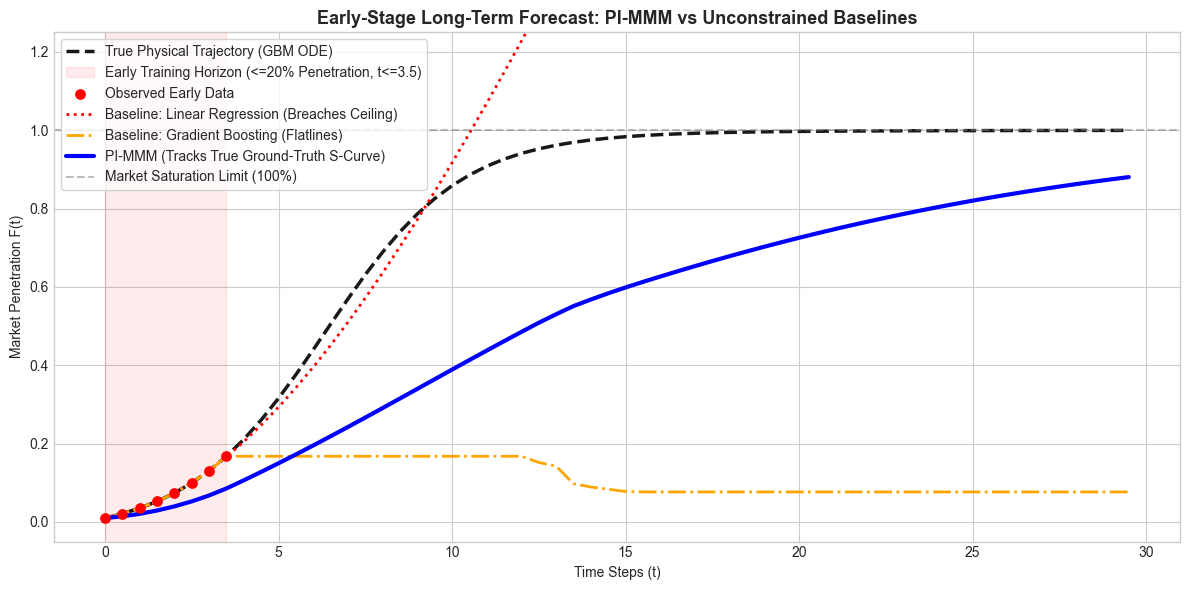